## Astronomy 3350
### Autumn 2025
#### Lab 5 - Exploring statistical estimators (September 30 and October 2)

__The setup:__ Suppose you have a collection of $N$ data values, not all of which are identical. Then you repeatedly take samples of size $k$ from this collection and compute statistics like the mean or standard deviation over the set of those samples. You might expect that if $k$ is small, there will be a lot variance in the any of these estimators, while if $k$ is large the values of the estimators will be similar..

In this lab we will explore this idea.  You will answer a set of questions based on inspection of data plots that are generated by this notebook.  Put your answers in Markdown cells below each figure, and then submit your notebook via Carmen Canvas.

The concepts here are described by an important statistical idea, the _central limit theorem_, which we will explore in detail later in lecture and in our reading.

You can study this notebook in detail for examples of plotting.  There will be many other examples which we will make available to you.

In the cells below I will define a number of functions that are needed in this lab.
You can ignore all of these and use the help() mechanism in Python
to get instructions for how to use any of the functions that are in the code
cells.  You can skip ahead to the cell that says __Start Here__.

In [1]:
# Import stuff
import matplotlib.pyplot as plt          # Plotting
import numpy as np                       # For generating random distributions

In [2]:
# plot aspect ratio
plt.rcParams['figure.figsize'] = [7,4]

# Mean of items in a list
def find_mean(values):
    """
    Returns the mean of data values stored in a list.
    """
    return sum(values) / len(values)

# Noral distribution
def gauss(mean, sigma, N):
    """
    Returns a python list with N values distributed normally
    around the designated mean and sigma.

    Arguments:
         mean       (float) the center of the normal distribution
         sigma      (float) the standard deviation
         N          (int)   number of points

    This code does a little error checking, returning an empty
    list if the input values are nonsensical.
    """
    # Check
    if sigma <= 0.0 or N <= 0:
        return []
    else:
        # We want a list, and not a numpy array
        return( list(np.random.normal(mean, sigma, N)) )  

# Cumulative distribution
def get_cd(x):
    """
    Returns the cumulative probability distribution for values
    contained in the list x.

    Input:
      x       (list) data values

    Returns two lists:
      sx, cd  respectively the sorted list and the cumulative distribution.
    """
    # Sorted copy of input list.
    sx = x.copy()
    sx.sort()

    # Cumulative distribution
    frac = 1.0 / len(x)
    cd = [ frac*(1+n) for n in range(len(x)) ]

    # Done
    return sx, cd

# Binned data
def gen_bin(values, nbin):
    """
    Uses list slicing to return the average index and the
    average values for bins of size nbin starting with index
    0 and running to the end of the list.
    """
    idx = [k for k in range(len(values))]
    bx = [ find_mean(idx[k : k+nbin]) for k in range(0, len(values), nbin)]
    by = [ find_mean(values[k : k+nbin]) for k in range(0, len(values), nbin)]
    return bx, by

# Mean absolute deviation
def find_mad(values):
    """
    Returns the average absolute deviation from the mean.
    """
    mean = find_mean(values)
    dev  = [ abs(mean - v) for v in values ]
    mad  = find_mean(dev)
    return mad


## Start here

### 1.  Consider a normal distribution

The Normal or Gaussian (or bell curve) distribution is characterized by two numbers, 
namely the mean $\langle x\rangle$ and the standard deviation $\sigma$.

- Use help(gauss) to learn how to generate a normal distribution with a mean and sigma of
your choice.
- Modify the code cell to put in values and generate a plot.  Then create a Markdown cell below the plot to answer questions about this plot.

In [3]:
# Uncomment this line to make it run
help(gauss)

Help on function gauss in module __main__:

gauss(mean, sigma, N)
    Returns a python list with N values distributed normally
    around the designated mean and sigma.
    
    Arguments:
         mean       (float) the center of the normal distribution
         sigma      (float) the standard deviation
         N          (int)   number of points
    
    This code does a little error checking, returning an empty
    list if the input values are nonsensical.



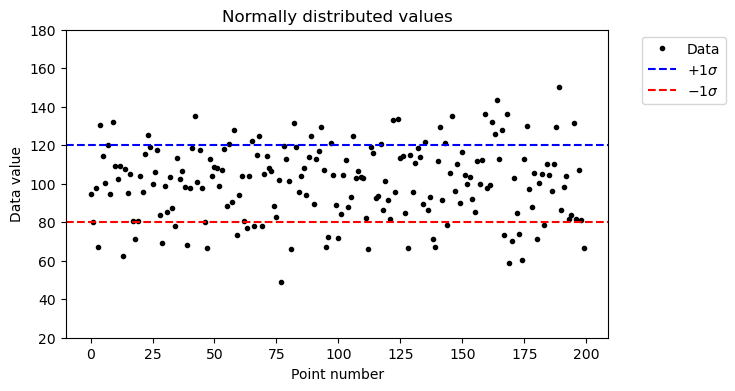

In [105]:
# --- Insert appropriate values
npoints = 200              # At least 50, not to exceed 200
gmean   = 100              # Mean
gsigma  = 20               # Standard deviation

# Get a normal distribution
mydist = gauss(gmean, gsigma, npoints)
if len(mydist) <= 0:
    print('Error in specification of normal distribution')
    () - 1           # Halt notebook with nonsensical code

# Show the data values and the binned mean.
fig, ax = plt.subplots()
ax.plot(mydist, '.k', label='Data')
ax.set_xlabel('Point number')
ax.set_ylabel('Data value')
ymin = gmean - 4 * gsigma
ymax = gmean + 4  *gsigma
ax.set_ylim(ymin, ymax)
ax.axhline(gmean+gsigma, color='b', linestyle='--', label=r'$+1\sigma$')
ax.axhline(gmean-gsigma, color='r', linestyle='--', label=r'$-1\sigma$')
ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
ax.set_title('Normally distributed values')
plt.show()

In [106]:
mydist_mean = find_mean(mydist)
mydist_mean

100.77403834515098

__Questions:__
1. Use the function `find_mean` to compute the mean of the list `mydist` generated above. Was the value exactly equal to the input value used to generate the distribution?  Why should it not be identical?  Is the data mean closer to the input value `gmean` if the number of points is large?
3. The dashed lines on the plot shows the interval $\pm 1\sigma$ around the mean.  Estimate the fraction of points that lie outside these dashed lines. You know how many points are on the plot because you specified it above.

__my answers here:__ 
The mean of the list mydist is about 100.5.(has been changed after I restart kernel and run all cells) The value is not exactly equal to the input value gmean = 100, but close to it, because standard deviation of mean with $\sigma = 20$ and N = 200 is:$\frac{\sigma}{\sqrt{N}}$ = $\frac{20}{\sqrt{200}} \approx 1.41$. So the computed sample mean should be within about ± 1.41 of 100. In simliar way, if N is large, assume 2000, SEM would be $\frac{20}{\sqrt{2000}}$ = 0.45, which means mean gets much closer to gmean.

The points outside the dashed lines I count are 55. Fraction is 0.275. For a true normal distribution, about 68.27% of observations lie within ±1 $\sigma$, which is about 136.54 points out of 200, fraction of 0.68. So, estimated fraction of points that lie outside the dashed lines is about 0.32

### 2. Examine the cumulative distribution.

The cumulative distribution shows the fraction of the sample below some value $x$.

Run the code below to plot the cumulative distribution, and answer the questions below the plot.  You can set values of `horiz` and `vert` to draw lines on the plot to help you estimate data value at selected places in the cumulative distribution.

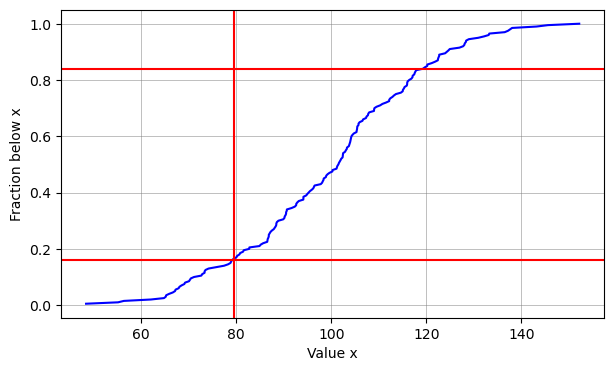

In [6]:
# Fetch the cumulative distribution.
values, frac = get_cd(mydist)

# Set values for guidelines
vert = min(mydist) + 0.3 * (max(mydist) - min(mydist)) # or some number you pick
horiz = 0.84
horiz_2 = 0.16

# Scribe the plot
fig, ax = plt.subplots()
ax.plot(values, frac, 'blue')
ax.set_xlabel('Value x')
ax.set_ylabel('Fraction below x')
ax.axhline(horiz_2, color='r')
ax.axhline(horiz, color='r')    # Guides: horizontal line at set y
ax.axvline(vert, color='r')     # Vertical line at set x
ax.grid(color='gray', linewidth=0.5, alpha=0.7)
plt.show()

__Questions:__

1. The median is that value which divides the sample in half by value.  Estimate the median using the plot above. How does it compare to the mean value used to generate the sample?
2. Estimate fraction of the sample that lies within $\pm 1\sigma$ of the mean.  How does that compare to the value you estimated that was _outside_ this interval above? Use the standard deviation value you used to generate the distribution.

__Your answers here:__
Fraction of 0.5 is median, about value of 99. For the symmetric normal distribution the median = mean. So, the median value should be very closed to gmean. 

fraction of the sample that lies within $\pm 1\sigma$ of the mean is about 0.68 as I said on problem 1 above. About fraction of 0.32 is outside of $\pm 1\sigma$, which I can see 0.16 of each tails. I can estimate these value of x are about below 80 and above 120

### 3. Examine the distribution of sample means.

In the code cell below, pick a sample size $k$ and run the cell.  This will bin
the distribution in groups of $k$, and will plot the means in each group.  Then,
below the plot, answer questions about the distribution of these means.

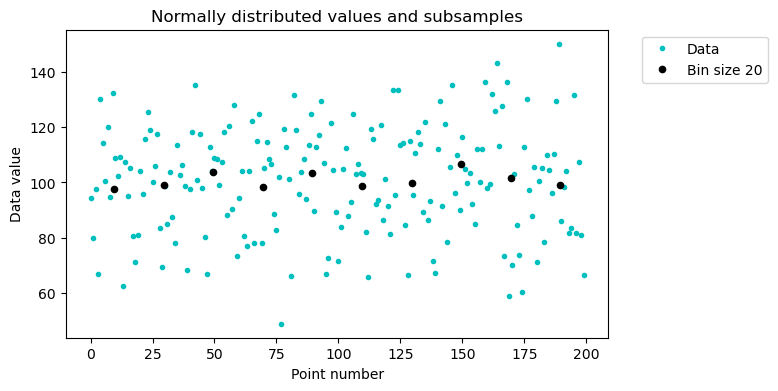

In [109]:
# Pick bin size much smaller than the size of the sample
k = 20                 # At least two, but probably larger

# Generate binned means
nindex = [ j for j in range(len(mydist)) ]
bindat_x, bindat_y = gen_bin(mydist, k)

# Show the data values and the binned mean.
fig, ax = plt.subplots()
ax.plot(mydist, '.c', label='Data')
ax.plot(bindat_x, bindat_y, '.k', label='Bin size %d' % k, markersize=9)
ax.set_xlabel('Point number')
ax.set_ylabel('Data value')
ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
ax.set_title('Normally distributed values and subsamples')
plt.show()

__Questions:__

1. From inspection of the plot, does it look like the mean of the whole sample and of the subsamples are similar?  What about the standard deviation?
2. Open up a code cell and compute the mean of the whole sample and of the set of subsamples.

__Your answers here:__
The means of subsamples cluster around the overall mean. The subsample means look very similar to the whole-sample mean. Standard Deviation of those averages: $\sigma_{\text{mean}} = \frac{\sigma}{\sqrt{k}}$. The cluster gets tighter as the bin size k increases.


In [111]:
# Mean of the whole sample
whole_mean = find_mean(mydist)
print("Mean of whole sample:", whole_mean)

# Mean of the subsample means
subsample_mean = find_mean(bindat_y)

print("Mean of subsample means:", subsample_mean)

## They are almost same

Mean of whole sample: 100.77403834515098
Mean of subsample means: 100.77403834515101


### 4. A goofy distribution

Let's explore what happens if we take subsamples of a distribution that is far from
normal.  We'll take the normal distribution created above, and create a new one with
value 0 if a data point is below the mean, and 1 if the value is above the mean.
In a first step, let's create that distribution and then plot it.

(-0.05, 1.05)

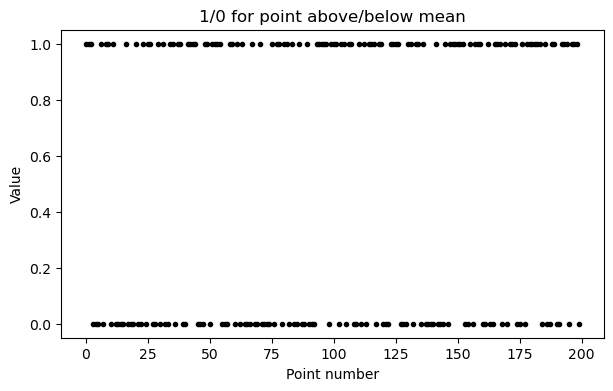

In [8]:
# Create the distribution with a list comprehension
goofy = [ 0.0 if v <= gmean else 1.0 for v in mydist ]

# Scribe the plot
fig, ax = plt.subplots()
ax.plot(goofy, '.k')
ax.set_xlabel('Point number')
ax.set_ylabel('Value')
ax.set_title('1/0 for point above/below mean')
ax.set_ylim(-0.05, 1.05)

We'll repeat the process of sampling this distribution with samples of size $k$, then examine how the variance depends on the sample size.

Here we define a statistic that works somewhat like the standard deviation but is simpler to compute.
We define a value $\Delta$,
called the _mean average deviation_, which is the mean of the absolute values of (mean - value).  If you run the cell below, the resulting plot will display the value of $\Delta$ for the set of subsamples.

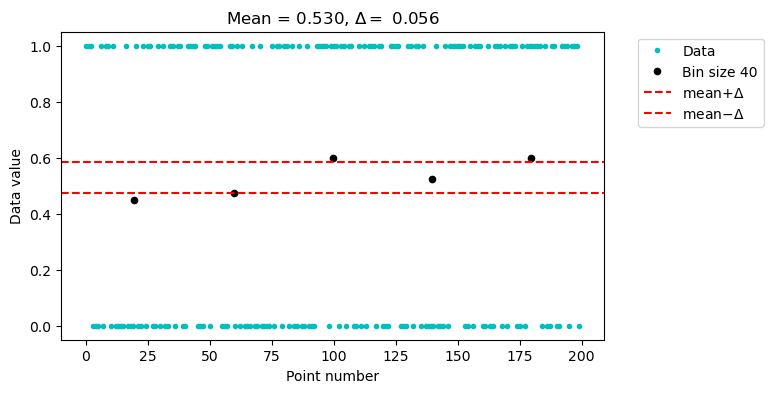

In [137]:
# Set bin size
k = 40


# Generate binned means
bindat_x, bindat_y = gen_bin(goofy, k)

# Show the data values and the binned mean.
fig, ax = plt.subplots()
ax.plot(goofy, '.c', label='Data')
ax.plot(bindat_x, bindat_y, '.k', label='Bin size %d' % k, markersize=9)
ax.set_xlabel('Point number')
ax.set_ylabel('Data value')
avgval = find_mean(bindat_y)
delta  = find_mad(bindat_y)
maxval = avgval + delta
minval = avgval - delta
ax.axhline(maxval, color='r', linestyle='--', label=r'mean$+\Delta$')    
ax.axhline(minval, color='r', linestyle='--', label=r'mean$-\Delta$')
titlestring = r'Mean = %.3f, $\Delta =$ %.3f' % (avgval, delta)
ax.set_title(titlestring)
ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()

__Instructions:__

Run the cell above with many different values of the bin size. Record
the values of $\Delta$ for the different bin sizes.

In the code cell below, assemble the value of the mean of the binned sample
and the value of $\Delta$ for various bin sizes from small (say 2) up to
up to a bin size = 1/4 of the size of the `goofy` sample.  Then run the cell to generate
a plot the value of $\Delta$ changes with
bin size. Describe what you think is happening.

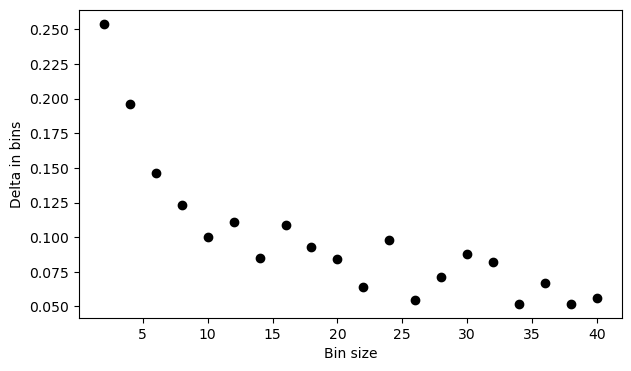

In [139]:
# Calculate
bin_sizes = [2, 4, 6, 8, 10, 12, 14, 16,18, 20,22,24,26,28,30,32,34,36,38,40]           # Populate this list
bin_delta = [0.254, 0.196, 0.146,0.123,0.1, 0.111, 0.085,0.109,0.093,0.084,0.064, 0.098, 0.055,0.071,0.088,0.082,0.052,0.067,0.052,0.056]    # Populate this list 

# Scribe the plot
fig, ax = plt.subplots()
ax.plot(bin_sizes, bin_delta, 'ok')
ax.set_xlabel('Bin size')
ax.set_ylabel('Delta in bins')
plt.show()

__Your answers here:__
As the bin size increases, the mean of each bin becomes more reliable because it is based on more data points. This reduces the random fluctuations in the bin means, so the Δ gets smaller.

__Important:__ When you are all finished:
- Use the Save operation to commit all changes.
- Run the whole notebook afresh using the double right arrow button.
- Download the notebook as an ipynb file and upload it to Carmen.